
Fe
  Number of atoms in unit cell : 2
  Lattice parameter            : 2.870 Å
  Volume                       : 23.640 Å³
  Sites                        : [PeriodicSite: Fe (0.0, 0.0, 0.0) [0.0, 0.0, 0.0], PeriodicSite: Fe (1.435, 1.435, 1.435) [0.5, 0.5, 0.5]]

Ni
  Number of atoms in unit cell : 4
  Lattice parameter            : 3.524 Å
  Volume                       : 43.763 Å³
  Sites                        : [PeriodicSite: Ni (0.0, 0.0, 0.0) [0.0, 0.0, 0.0], PeriodicSite: Ni (1.762, 1.762, 0.0) [0.5, 0.5, 0.0], PeriodicSite: Ni (1.762, 0.0, 1.762) [0.5, 0.0, 0.5], PeriodicSite: Ni (0.0, 1.762, 1.762) [0.0, 0.5, 0.5]]

Cr
  Number of atoms in unit cell : 2
  Lattice parameter            : 2.884 Å
  Volume                       : 23.988 Å³
  Sites                        : [PeriodicSite: Cr (0.0, 0.0, 0.0) [0.0, 0.0, 0.0], PeriodicSite: Cr (1.442, 1.442, 1.442) [0.5, 0.5, 0.5]]


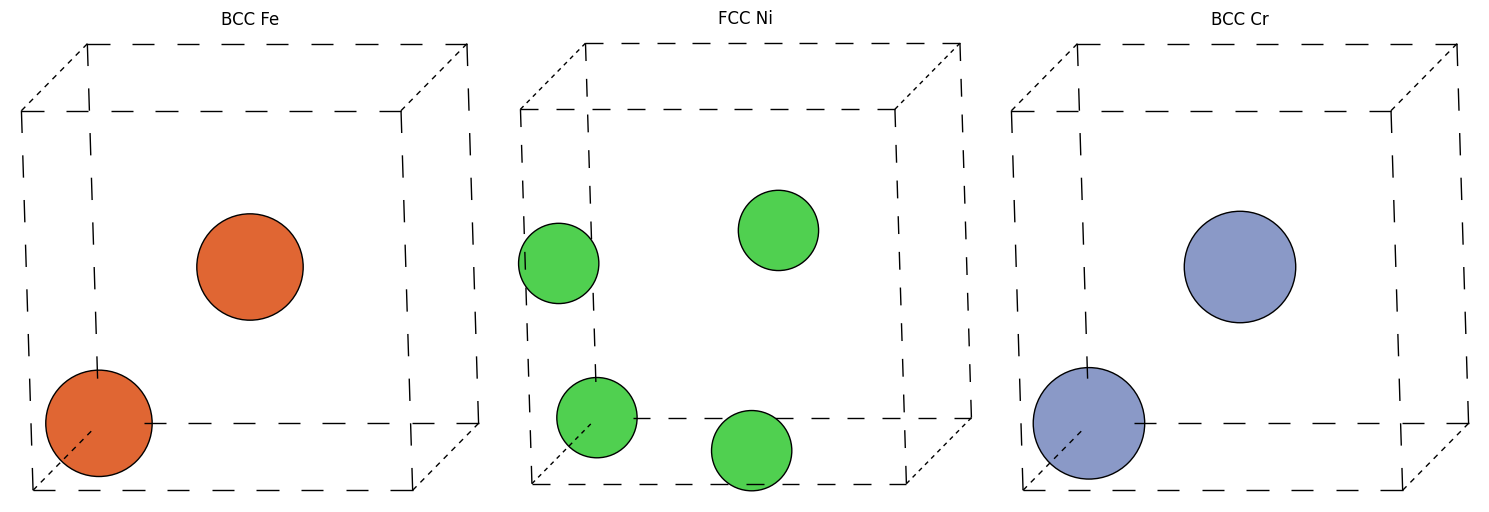

In [ ]:
from ase.build import bulk
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
import numpy as np
from pymatgen.core import Structure, Lattice, Element, Composition
from pymatgen.io.ase import AseAtomsAdaptor
# Structure = the full crystal (lattice + atoms)
# Lattice   = defines the unit cell box (size and shape)
# Element, Composition = tools for working with elements and alloy compositions


# ── UNARY: SINGLE ELEMENTS ───────────────────────────────────────────────────

# Build FCC Nickel using pymatgen
ni = Structure.from_spacegroup("Fm-3m", Lattice.cubic(3.524), ["Ni"], [[0, 0, 0]])
# "Fm-3m": FCC space group, a=3.524 Å

# Build BCC Iron using pymatgen
fe = Structure.from_spacegroup("Im-3m", Lattice.cubic(2.870), ["Fe"], [[0, 0, 0]])
# "Im-3m": BCC space group, a=2.870 Å

# Build BCC Chromium using pymatgen
cr = Structure.from_spacegroup("Im-3m", Lattice.cubic(2.884), ["Cr"], [[0, 0, 0]])
# from_spacegroup: builds full crystal using symmetry rules — no need to type every atom
# Lattice.cubic(2.884): defines unit cell box — all sides 2.884 Å, all angles 90°
# ["Cr"]: element placed at the starting position
# [[0,0,0]]: one unique atom position — pymatgen uses Im-3m symmetry to auto-generate
#            the body-centre atom at [0.5, 0.5, 0.5]

for name, structure in [("Fe", fe), ("Ni", ni), ("Cr", cr)]:
    print(f"\n{name}")
    print(f"  Number of atoms in unit cell : {len(structure)}")
    print(f"  Lattice parameter            : {structure.lattice.a:.3f} Å")
    print(f"  Volume                       : {structure.volume:.3f} Å³")
    print(f"  Sites                        : {structure.sites}")

# ── VISUALISATION ─────────────────────────────────────────────────────────────

adaptor = AseAtomsAdaptor()
# Converts pymatgen Structure → ASE Atoms so plot_atoms can render them

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, structure) in zip(axes, [("BCC Fe", fe), ("FCC Ni", ni), ("BCC Cr", cr)]):
    ase_atoms = adaptor.get_atoms(structure)
    plot_atoms(ase_atoms, ax, radii=0.3, rotation="10x,-10y,0z")
    ax.set_title(name)

plt.tight_layout()
plt.show()

# Shows the atom positions within one unit cell
# Corner atoms appear as full circles but are shared across 8 neighbouring unit cells (each cell owns 1/8)
# Face atoms are shared across 2 neighbouring unit cells (each cell owns 1/2)
# The visualisation shows position only, not fractional ownership
